# One-Hot Encoding, Label Encoding

##### what are Categorical Variables?
The labels or features that represent discreate categories 
 - **Binary Categorical Features** : Gender (Male/Female)
 - **Multi-Class Categorical Feature:** Contry(USA,Canada, UK)
  
Categorical Input -> Numerical Inputs

---

### One-Hot Encoding
- Created binary columns for each category in a categorical feature
- Each row is marked with a 1 for its respective category and 0 elsewhere
  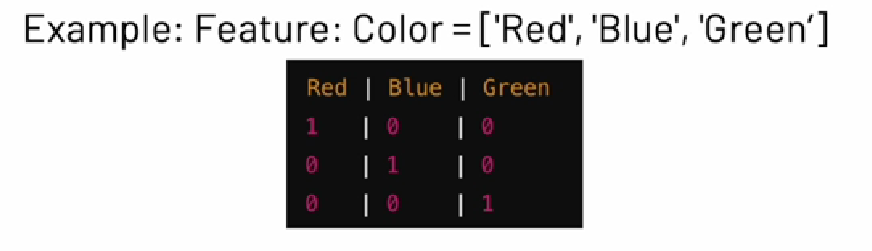

- Applications
  - Categorical features with small number of unique categories
  - Tree-based models, logistic regression, and neural network

### Label Encoding
It assign a unique integer to each category

Example: Red = 0, Blue = 1, Green =2

- Applications:
  - Ordinal features where order matters, example high school < Bachelors < Masters
  - Can introduce unintended ordinal relationships for nominal features
- Limitations
  - Can Mislead algorithms into interpreting categories as ordered, especially when the variable is nominal

#### Dealing with High-Cardinality Categorical Features
- High-cardinality: type of data where a categorical variable has a very large number of unique values.
- **Challenges**
  1. **Dimentionality** : one-hot encoding will create too many columns, which increases computational cost
  2. **Sparse Representation** : Many columns has the value of 0, leading to the sparcity of the dataset
- **Solutions**
  1. **Frequency Encoding** : replace categories with their occurence frequency in the dataset
   - Example: City ['NY','LA','NY','SF','LA'] Encoded: NY=2, LA=2, SF=1
  2. **Target Encoding:** Replace categories with the mean of the target variable for each category

### When to use Different Encoding Technique
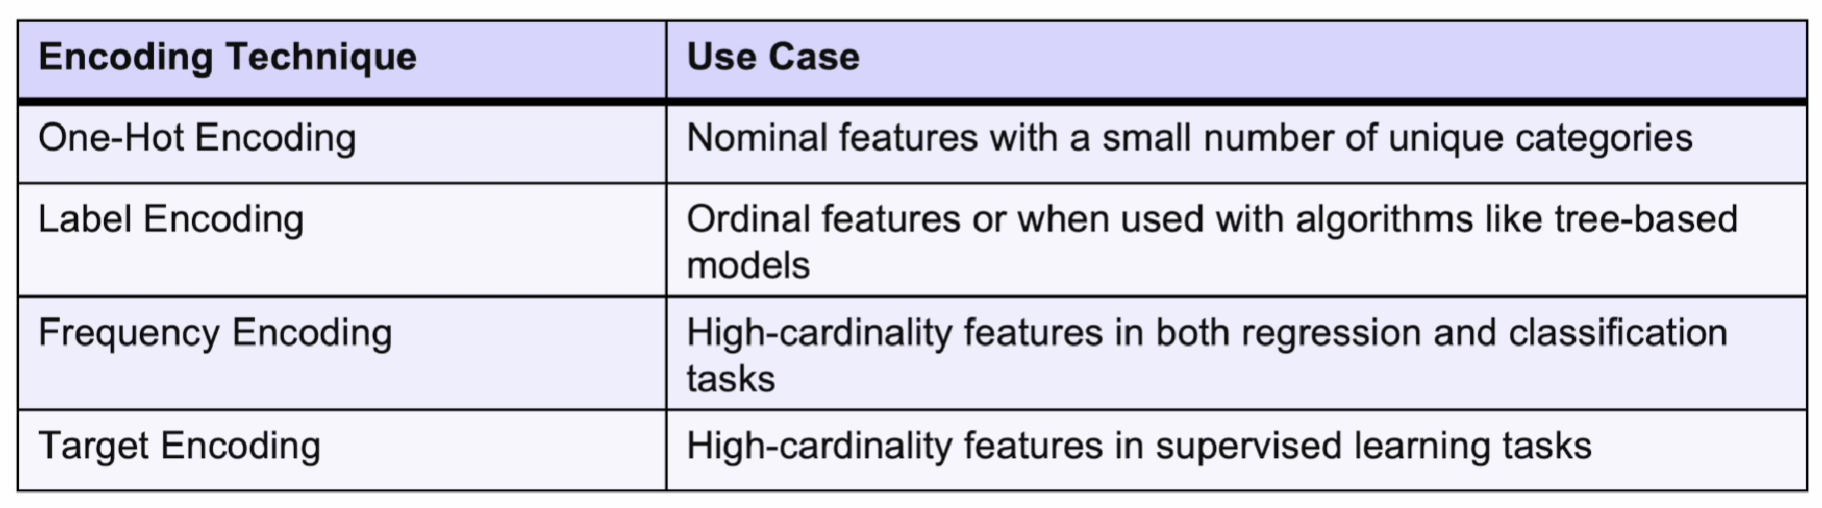

---

### Hands-On
- Apply One-Hot Encoding and Label Encoding to a dataset with categorical variables
- Experiment with differnt encoding techniques and observe their impact on model performance

In [44]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [45]:
# Display dataset infromation
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [46]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


---

### Apply One-Hot Encoding

This parameter tells pd.get_dummies() to create dummy variables for your categorical columns ('Sex' and 'Embarked'), but to drop the first category of each feature that it encounters.

By doing this, it encodes N categories into N-1 new columns, with the Nth category represented by all zeros.

drop_first=True doesn't just remove the heading; it removes the entire column of data for the first category.
This creates a new dataframe with new columns. The original 'Sex' column is removed, but it's replaced with new columns that contain the same information.

- pd.get_dummies would look at the categories: 'female' and 'male'.

- The first one (alphabetically) is 'female'.

- drop_first=True tells the function to not create a column for 'female'.

- It creates a new column for 'male' and the output looks like this:

**It adds some more features and removes some of them also**

In [47]:
# Apply one hot encoding
df_one_hot = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print(df_one_hot.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN      True       False        True  
1          PC 17599  71.2833   C85     False       False       False  
2  STON/O2. 3101282   7.9250   NaN     False       False        True  
3            113803  53.1000  C123     Fal

---


#### Applying Label Encoding

In [48]:
label_encoder = LabelEncoder()
df['Pclass_encoded'] = label_encoder.fit_transform(df['Pclass'])

In [49]:
# Display
print("Label Encoded Dataset")
print(df[['Pclass','Pclass_encoded']].head())

Label Encoded Dataset
   Pclass  Pclass_encoded
0       3               2
1       1               0
2       3               2
3       1               0
4       3               2


---

### Dealing with high cardinality datasets like tickets using frequency Encoding

In [50]:
# Apply Frequency Encoding
df['Ticket_frenquency'] = df['Ticket'].map(df['Ticket'].value_counts())
# Display frequency encoded feature
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  Pclass_encoded  \
0      0         A/5 21171   7.2500   NaN        S               2   
1      0          PC 17599  71.2833   C85        C               0   
2      0  STON/O2. 3101282   7.9250   NaN        S               2   
3      0            113803  53.1000  C12

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [52]:
X = df_one_hot.drop(columns=['Survived','Name','Ticket','Cabin'])
y = df['Survived']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


The error in your code is likely due to missing values (NaNs) in your features after one-hot encoding, or possibly in the columns you are using for training.

LogisticRegression from scikit-learn cannot handle missing values directly.

In [54]:
# Check for missing values in your feature
print(X_train.isnull().sum())
print(X_test.isnull().sum())

PassengerId      0
Pclass           0
Age            140
SibSp            0
Parch            0
Fare             0
Sex_male         0
Embarked_Q       0
Embarked_S       0
dtype: int64
PassengerId     0
Pclass          0
Age            37
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64


In [55]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [56]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [57]:
y_pred = model.predict(X_test)
print("Accuracy with One-Hot Encoding:", accuracy_score(y_test, y_pred))

Accuracy with One-Hot Encoding: 0.7821229050279329
